In [1]:
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
import math
import pickle
from tqdm import tqdm
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
import pandas as pd
import os 
import sys
import cvxpy as cp
module_path = 'C:/Users/danie/Documents/Multi-Secretary-Dyn-Approx/Code/'
sys.path.append(module_path)
sys.setrecursionlimit(3500)

In [2]:
A = np.array([[1., 1., 0.],
              [1., 0., 1.],
              [0., 1., 1.]])

In [3]:
def dynamic_continuous_multidimensional(T, capacity):
    T = int(T); capacity = int(capacity)
    val = np.zeros((T+1, capacity+1, capacity+1), dtype=np.float64)
    sol = np.zeros((2, T+1, capacity+1, capacity+1), dtype=np.float64)  # store optimal a1,a2

    for t in tqdm(range(1, T+1)):
        xmax = capacity
        ymax = capacity

        Vs = val[t-1]  # alias for previous layer, shape (capacity+1, capacity+1)

        # ----- finite differences for a1 and a2 (vectorized over x=1..xmax, y=0..ymax) -----
        # a1 uses backward diff in x: V(x,y) - V(x-1,y)
        dx = Vs[1:xmax+1, :ymax+1] - Vs[0:xmax, :ymax+1]                  # (xmax, ymax+1)
        a1 = np.clip(dx, 0.0, 1.0)

        # a2: y=0 boundary -> a2=1; for y>=1 use diagonal diff V(x,y)-V(x-1,y-1)
        a2 = np.empty_like(a1)
        a2[:, 0] = 1.0
        if ymax >= 1:
            dd = Vs[1:xmax+1, 1:ymax+1] - Vs[0:xmax, 0:ymax]              # (xmax, ymax)
            a2[:, 1:] = np.clip(dd, 0.0, 1.0)

        # ----- value update terms (all shapes (xmax, ymax+1)) -----
        # constants from immediate reward
        inc = 0.25*(1.0 - a1*a1) + 0.25*(1.0 - a2*a2)

        # transitions to previous-layer states
        term1 = 0.5*(1.0 - a1) * Vs[0:xmax, :ymax+1]                      # to (x-1, y)

        term2 = np.zeros_like(a1)                                         # to (x-1, y-1)
        if ymax >= 1:
            term2[:, 1:] = 0.5*(1.0 - a2[:, 1:]) * Vs[0:xmax, 0:ymax]

        term3 = 0.5*(a1 + a2) * Vs[1:xmax+1, :ymax+1]                     # stay at (x, y)

        # write the updated layer
        val[t, 1:xmax+1, :ymax+1] = inc + term1 + term2 + term3

        # store policy
        sol[0, t, 1:xmax+1, :ymax+1] = a1
        sol[1, t, 1:xmax+1, :ymax+1] = a2

        # ----- (optional) sanity checks -----

    return val, sol


def deterministic_closed_form(t, x1, x2):
    """
    Scalar closed form for one (t, x1, x2).
    Returns u1, u2, value.
    """
    t = float(t)
    s = 2.0 * x1 / t
    c2 = min(1.0, 2.0 * x2 / t)

    u2 = min(c2, 0.5 * s)
    u1 = min(1.0, s - u2)

    val = t * (0.5 * (u1 - 0.5 * u1 * u1) + 0.5 * (u2 - 0.5 * u2 * u2))
    return u1, u2, val

def deterministic_multidimensional_array(T, capacity):
    """
    Vectorized table: val[t, x1, x2] for t=1..T and x1,x2=0..min(capacity,t).
    Uses the closed-form solution above.
    """
    T = int(T); capacity = int(capacity)
    val = np.zeros((T+1, capacity+1, capacity+1), dtype=np.float64)

    for t in tqdm(range(1, T+1)):
        n = capacity + 1

        # grids for x1 (rows) and x2 (cols) of shape (n, n)
        X1 = np.arange(n).reshape(n, 1)
        X2 = np.arange(n).reshape(1, n)

        s  = 2.0 * X1 / t                         # total budget bound for u1+u2
        c2 = np.minimum(1.0, 2.0 * X2 / t)        # individual cap for u2

        u2 = np.minimum(c2, 0.5 * s)
        u1 = np.minimum(1.0, s - u2)

        # value: t * [ 0.5(u - 0.5u^2) + 0.5(u - 0.5u^2) ]
        val_layer = t * (0.5 * (u1 - 0.5 * u1 * u1) + 0.5 * (u2 - 0.5 * u2 * u2))

        val[t, :n, :n] = val_layer

    return val



def lookahead_continuous_multidimensional(T, capacity, val_deterministic):
    T = int(T); capacity = int(capacity)
    val = np.zeros((T+1, capacity+1, capacity+1), dtype=np.float64)
    sol = np.zeros((2, T+1, capacity+1, capacity+1), dtype=np.float64)  # store optimal a1,a2

    for t in tqdm(range(1, T+1)):
        xmax = capacity
        ymax = capacity

        Vs = val[t-1]  # alias for previous layer, shape (capacity+1, capacity+1)
        Vs2 = val_deterministic[t-1]  # use deterministic value function for lookahead

        # ----- finite differences for a1 and a2 (vectorized over x=1..xmax, y=0..ymax) -----
        # a1 uses backward diff in x: V(x,y) - V(x-1,y)
        dx = Vs2[1:xmax+1, :ymax+1] - Vs2[0:xmax, :ymax+1]                  # (xmax, ymax+1)
        a1 = np.clip(dx, 0.0, 1.0)

        # a2: y=0 boundary -> a2=1; for y>=1 use diagonal diff V(x,y)-V(x-1,y-1)
        a2 = np.empty_like(a1)
        a2[:, 0] = 1.0
        if ymax >= 1:
            dd = Vs2[1:xmax+1, 1:ymax+1] - Vs2[0:xmax, 0:ymax]              # (xmax, ymax)
            a2[:, 1:] = np.clip(dd, 0.0, 1.0)

        # ----- value update terms (all shapes (xmax, ymax+1)) -----
        # constants from immediate reward
        inc = 0.25*(1.0 - a1*a1) + 0.25*(1.0 - a2*a2)

        # transitions to previous-layer states
        term1 = 0.5*(1.0 - a1) * Vs[0:xmax, :ymax+1]                      # to (x-1, y)

        term2 = np.zeros_like(a1)                                         # to (x-1, y-1)
        if ymax >= 1:
            term2[:, 1:] = 0.5*(1.0 - a2[:, 1:]) * Vs[0:xmax, 0:ymax]

        term3 = 0.5*(a1 + a2) * Vs[1:xmax+1, :ymax+1]                     # stay at (x, y)

        # write the updated layer
        val[t, 1:xmax+1, :ymax+1] = inc + term1 + term2 + term3

        # store policy
        sol[0, t, 1:xmax+1, :ymax+1] = a1
        sol[1, t, 1:xmax+1, :ymax+1] = a2

        # ----- (optional) sanity checks -----

    return val, sol


In [4]:
T=500
capacity=500

In [5]:
val_dynamic, sol_dynamic = dynamic_continuous_multidimensional(T, capacity)

100%|██████████| 500/500 [00:05<00:00, 83.40it/s]


In [6]:
val_deterministic = deterministic_multidimensional_array(T, capacity)

100%|██████████| 500/500 [00:02<00:00, 173.28it/s]


In [7]:
val_lookahead, sol_lookahead = lookahead_continuous_multidimensional(T, capacity, val_deterministic)

100%|██████████| 500/500 [00:06<00:00, 82.84it/s]


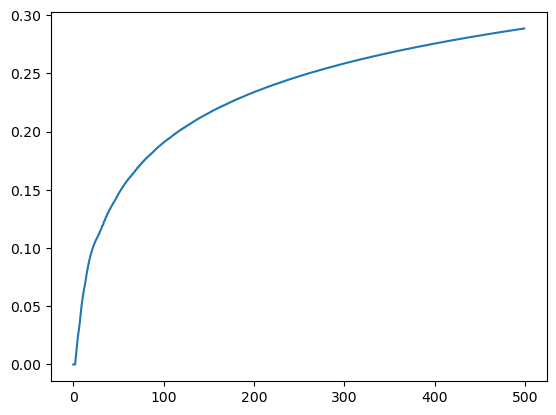

In [16]:
sub_gap = np.zeros((T))
for t in range(2,T):
    sub_gap[t] = np.max(val_dynamic[t,:,:] - val_lookahead[t,:,:])

plt.plot(sub_gap)
plt.show()

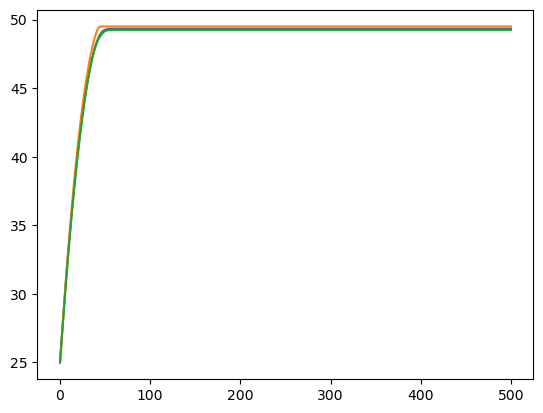

In [9]:
plt.plot(val_dynamic[100, 90, :])
plt.plot(val_deterministic[100, 90, :])
plt.plot(val_lookahead[100, 90, :])
plt.show()

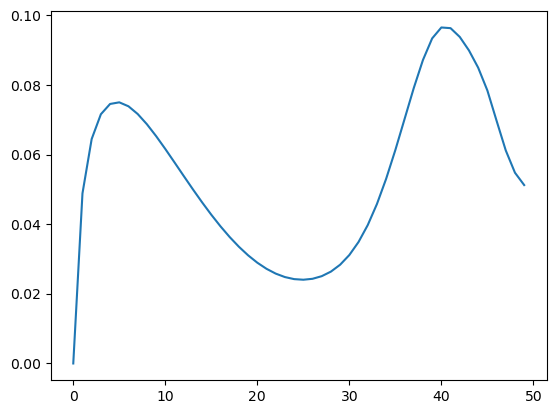

In [17]:
plt.plot(val_dynamic[50, :50, 20]- val_lookahead[50, :50, 20])

In [11]:
sol_dynamic.shape

(2, 501, 501, 501)

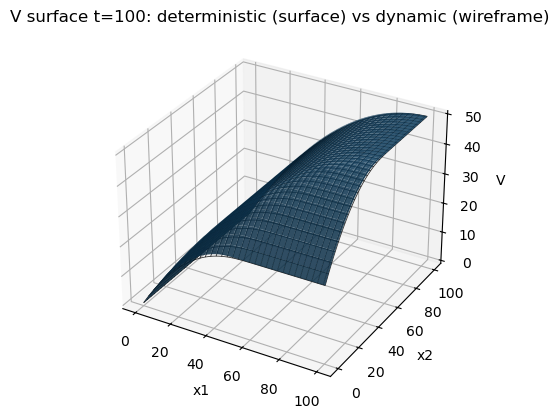

In [12]:

t = 100
n = min(capacity, t) + 1
X1, X2 = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")

Z_det = val_deterministic[t, :n, :n]
Z_dyn = val_dynamic[t, :n, :n]

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# deterministic as surface
surf = ax.plot_surface(X1, X2, Z_det, linewidth=0, antialiased=True, alpha=0.85)

# dynamic as wireframe overlay (readable on top of the surface)
ax.plot_wireframe(X1, X2, Z_dyn, rstride=3, cstride=3, color='k', linewidth=0.6, alpha=0.8)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("V")
ax.set_title(f"V surface t={t}: deterministic (surface) vs dynamic (wireframe)")
plt.show()

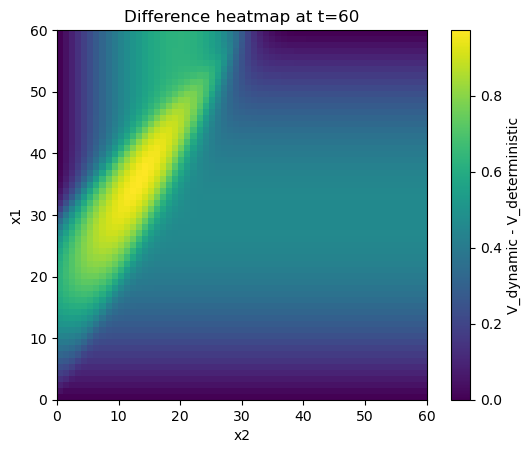

In [13]:
t = 60
n = min(capacity, t) + 1
diff =val_deterministic[t, :n, :n] - val_dynamic[t, :n, :n] 

plt.figure()
plt.imshow(diff, origin="lower", extent=[0, n-1, 0, n-1], aspect="equal")
plt.colorbar(label="V_dynamic - V_deterministic")
plt.xlabel("x2"); plt.ylabel("x1")
plt.title(f"Difference heatmap at t={t}")
plt.show()

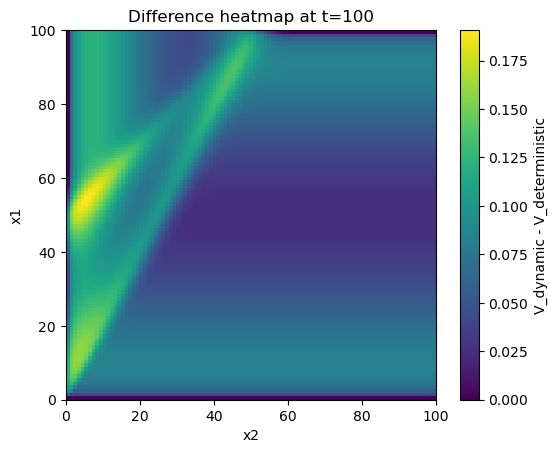

In [15]:
t = 100
n = min(capacity, t) + 1
diff =val_dynamic[t, :n, :n] - val_lookahead[t, :n, :n] 

plt.figure()
plt.imshow(diff, origin="lower", extent=[0, n-1, 0, n-1], aspect="equal")
plt.colorbar(label="V_dynamic - V_deterministic")
plt.xlabel("x2"); plt.ylabel("x1")
plt.title(f"Difference heatmap at t={t}")
plt.show()

In [18]:
import matplotlib.pyplot as plt

def compare_policies_at_t(t, sol_dynamic, sol_deterministic, capacity):
    n = min(capacity, t) + 1

    # a1: compare on x1=1..n-1, x2=0..n-1
    a1_dyn = sol_dynamic[0, t, 1:n, :n]
    a1_det = sol_deterministic[0, t, 1:n, :n]
    diff_a1 = a1_dyn - a1_det

    # a2: compare on x1=1..n-1, x2=1..n-1 (avoid boundary mismatch at x2=0)
    if n >= 2:
        a2_dyn = sol_dynamic[1, t, 1:n, 1:n]
        a2_det = sol_deterministic[1, t, 1:n, 1:n]
        diff_a2 = a2_dyn - a2_det
    else:
        a2_dyn = a2_det = diff_a2 = np.zeros((0,0))

    # --- Heatmaps of differences ---
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    im1 = axs[0].imshow(diff_a1, origin='lower', aspect='equal',
                        extent=[0, n-1, 1, n-1])
    axs[0].set_title(f"a1: dynamic - deterministic (t={t})")
    axs[0].set_xlabel("x2"); axs[0].set_ylabel("x1")
    plt.colorbar(im1, ax=axs[0])

    im2 = axs[1].imshow(diff_a2, origin='lower', aspect='equal',
                        extent=[1, n-1, 1, n-1])
    axs[1].set_title(f"a2: dynamic - deterministic (t={t})")
    axs[1].set_xlabel("x2"); axs[1].set_ylabel("x1")
    plt.colorbar(im2, ax=axs[1])

    plt.tight_layout()
    plt.show()

    # --- Scatter: calibration plots ---
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].scatter(a1_det.ravel(), a1_dyn.ravel(), s=6, alpha=0.5)
    axs[0].plot([0,1], [0,1], 'k--', linewidth=1)
    axs[0].set_title(f"a1 calibration (t={t})")
    axs[0].set_xlabel("deterministic u1"); axs[0].set_ylabel("dynamic a1")

    if a2_dyn.size:
        axs[1].scatter(a2_det.ravel(), a2_dyn.ravel(), s=6, alpha=0.5)
        axs[1].plot([0,1], [0,1], 'k--', linewidth=1)
        axs[1].set_title(f"a2 calibration (t={t})")
        axs[1].set_xlabel("deterministic u2"); axs[1].set_ylabel("dynamic a2")
    else:
        axs[1].axis('off')

    plt.tight_layout()
    plt.show()

    # --- Simple error metrics ---
    mae_a1 = float(np.mean(np.abs(diff_a1)))
    linf_a1 = float(np.max(np.abs(diff_a1)))
    if a2_dyn.size:
        mae_a2 = float(np.mean(np.abs(diff_a2)))
        linf_a2 = float(np.max(np.abs(diff_a2)))
    else:
        mae_a2 = linf_a2 = np.nan

    print(f"[t={t}]  a1: MAE={mae_a1:.4e}, L_inf={linf_a1:.4e}   |   a2: MAE={mae_a2:.4e}, L_inf={linf_a2:.4e}")


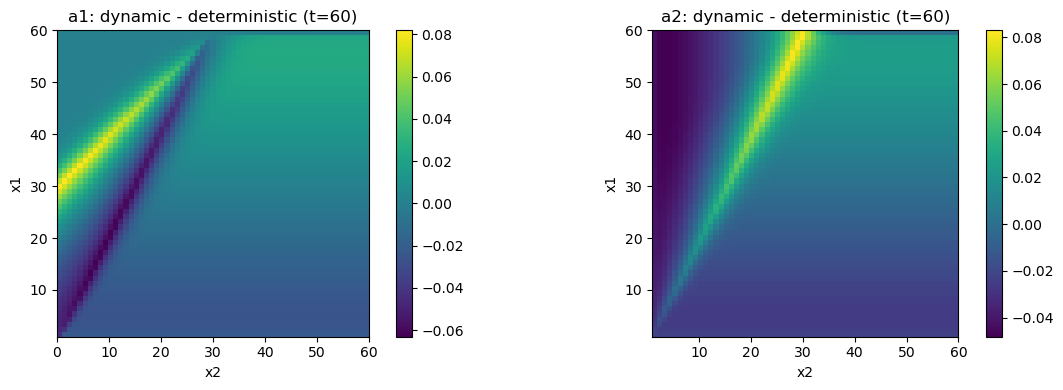

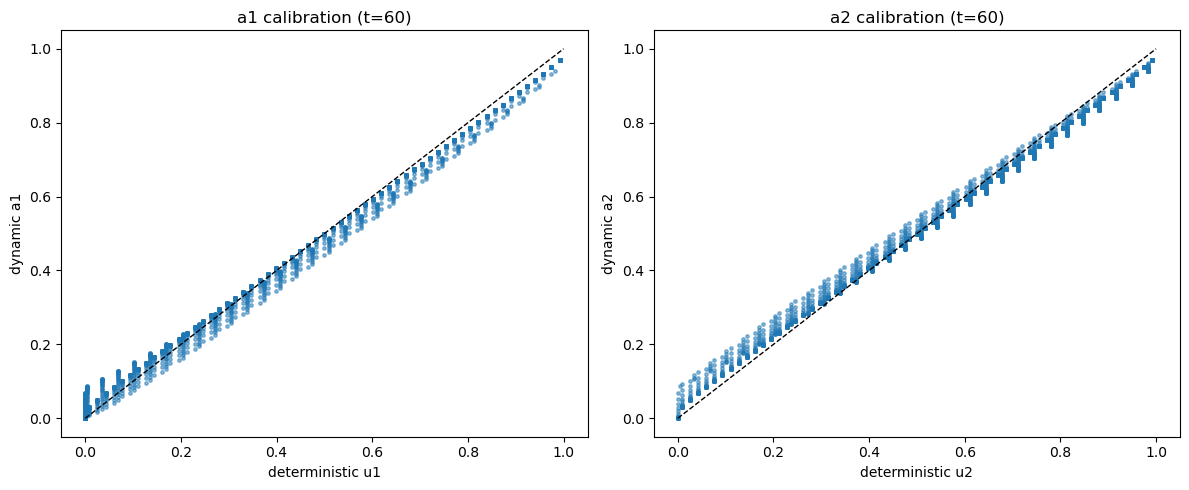

[t=60]  a1: MAE=1.7277e-02, L_inf=8.1911e-02   |   a2: MAE=2.0580e-02, L_inf=8.3029e-02


In [19]:
t = 60
compare_policies_at_t(t, sol_dynamic, sol_lookahead, capacity)


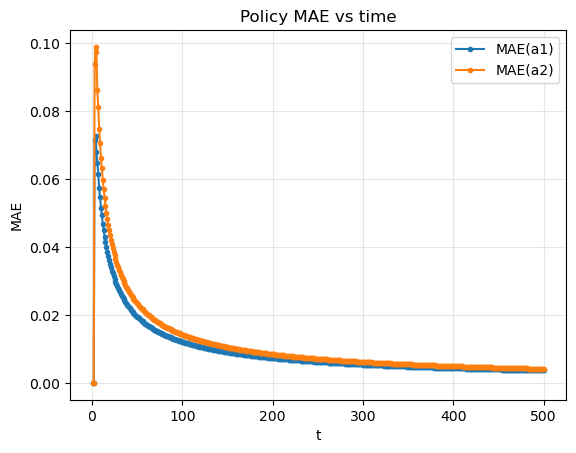

In [20]:
def policy_mae_over_time(sol_dynamic, sol_deterministic, T, capacity):
    ts = np.arange(1, T+1)
    mae_a1, mae_a2 = [], []

    for t in ts:
        n = min(capacity, t) + 1
        # a1 on x1>=1, x2>=0
        d1 = sol_dynamic[0, t, 1:n, :n] - sol_deterministic[0, t, 1:n, :n]
        mae_a1.append(np.mean(np.abs(d1)))

        # a2 on x1>=1, x2>=1
        if n >= 2:
            d2 = sol_dynamic[1, t, 1:n, 1:n] - sol_deterministic[1, t, 1:n, 1:n]
            mae_a2.append(np.mean(np.abs(d2)))
        else:
            mae_a2.append(np.nan)

    import matplotlib.pyplot as plt
    plt.figure()
    plt.plot(ts, mae_a1, marker='.', label='MAE(a1)')
    plt.plot(ts, mae_a2, marker='.', label='MAE(a2)')
    plt.xlabel('t'); plt.ylabel('MAE'); plt.legend(); plt.grid(True, alpha=0.3)
    plt.title('Policy MAE vs time')
    plt.show()

# Example:
policy_mae_over_time(sol_dynamic, sol_lookahead, T, capacity)


Finite MAE(a1): 500/500
Finite MAE(a2): 500/500


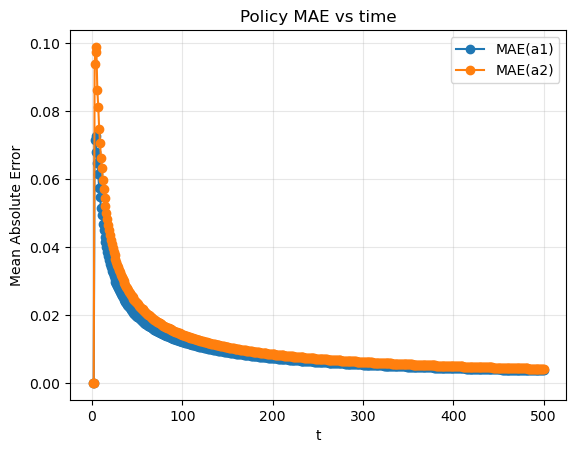

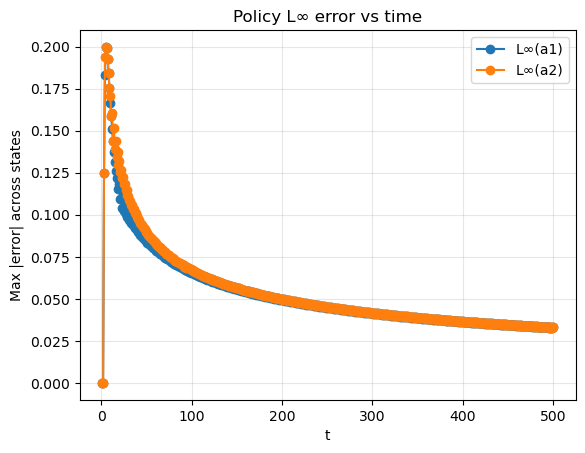

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def policy_errors_over_time(sol_dynamic, sol_deterministic, T, capacity):
    # 1. Pre-allocate storage
    ts        = np.arange(1, T + 1)
    mae_a1    = np.full(T, np.nan)
    mae_a2    = np.full(T, np.nan)
    linf_a1   = np.full(T, np.nan)
    linf_a2   = np.full(T, np.nan)

    # 2. Loop over all time steps
    for i, t in enumerate(ts):
        n = min(capacity, t) + 1

        # --- a1 comparison: x1>=1, x2>=0 ---
        d1 = sol_dynamic[0, t, 1:n, :n] - sol_deterministic[0, t, 1:n, :n]
        if d1.size:
            mae_a1[i]  = np.nanmean(np.abs(d1))
            linf_a1[i] = np.nanmax(np.abs(d1))

        # --- a2 comparison: x1>=1, x2>=1 (skip boundary mismatch at x2=0) ---
        if n >= 2:
            d2 = sol_dynamic[1, t, 1:n, 1:n] - sol_deterministic[1, t, 1:n, 1:n]
            mae_a2[i]  = np.nanmean(np.abs(d2))
            linf_a2[i] = np.nanmax(np.abs(d2))

    # 3. Print quick diagnostics
    print(f"Finite MAE(a1): {np.sum(np.isfinite(mae_a1))}/{T}")
    print(f"Finite MAE(a2): {np.sum(np.isfinite(mae_a2))}/{T}")

    # 4. Plot MAE curves
    plt.figure()
    plt.plot(ts, mae_a1, marker='o', label='MAE(a1)')
    plt.plot(ts, mae_a2, marker='o', label='MAE(a2)')
    plt.xlabel("t")
    plt.ylabel("Mean Absolute Error")
    plt.title("Policy MAE vs time")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    # 5. Plot L∞ curves
    plt.figure()
    plt.plot(ts, linf_a1, marker='o', label='L∞(a1)')
    plt.plot(ts, linf_a2, marker='o', label='L∞(a2)')
    plt.xlabel("t")
    plt.ylabel("Max |error| across states")
    plt.title("Policy L∞ error vs time")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    return ts, mae_a1, mae_a2, linf_a1, linf_a2

ts, mae_a1, mae_a2, linf_a1, linf_a2 = policy_errors_over_time(
    sol_dynamic, sol_lookahead, T, capacity
)


